In [ ]:
print("Sales Prediction Project Started")

Sales Prediction Project Started


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/RPI-DATA/tutorials-intro/master/rossmann-store-sales/rossmann-store-sales/train.csv"

train = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Rows:", len(train))
print("Columns:", len(train.columns))

train.head()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
print("Dataset Shape:", train.shape)

print("\nColumn Names:")
print(train.columns.tolist())

print("\nDataset Information:")
train.info()

Dataset Shape: (1017209, 9)

Column Names:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [ ]:
print("Missing values:")
print(train.isnull().sum())

print("\nDuplicate rows:")
print(train.duplicated().sum())

print("\nBasic statistics:")
display(train.describe())

Missing values:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Duplicate rows:
0

Basic statistics:


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
# Save the downloaded dataset inside our project
output_path = "../DATASET/train.csv"

train.to_csv(output_path, index=False)

print("Dataset saved successfully!")
print("Saved to:", output_path)

Dataset saved successfully!
Saved to: ../DATASET/train.csv


In [ ]:
# Basic sales analysis

print("Sales Summary:")
print(train["Sales"].describe())

print("\nNumber of stores:", train["Store"].nunique())
print("Date range:", train["Date"].min(), "to", train["Date"].max())

print("\nAverage sales when store is open:")
print(train.loc[train["Open"] == 1, "Sales"].mean())

print("\nAverage sales during promotion:")
print(train.loc[train["Promo"] == 1, "Sales"].mean())

print("\nAverage sales without promotion:")
print(train.loc[train["Promo"] == 0, "Sales"].mean())

Sales Summary:
count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

Number of stores: 1115
Date range: 2013-01-01 to 2015-07-31

Average sales when store is open:
6955.514290755952

Average sales during promotion:
7991.152045969903

Average sales without promotion:
4406.050805160786


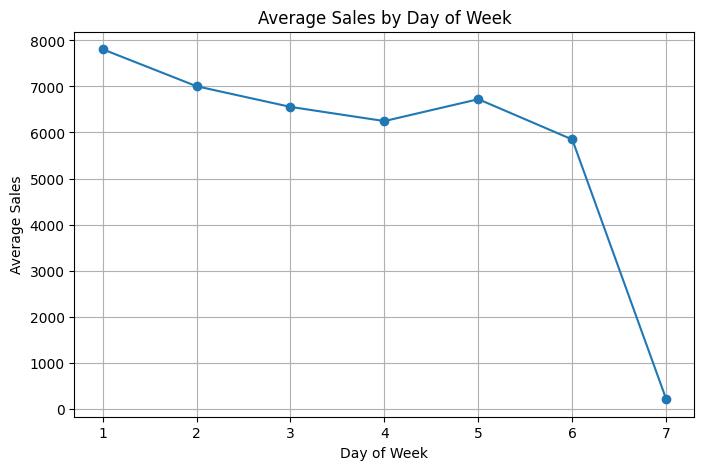

In [ ]:
import matplotlib.pyplot as plt

# Calculate average sales for each day of the week
avg_sales_by_day = train.groupby("DayOfWeek")["Sales"].mean()

plt.figure(figsize=(8, 5))
plt.plot(avg_sales_by_day.index, avg_sales_by_day.values, marker="o")
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(range(1, 8))
plt.grid(True)
plt.show()


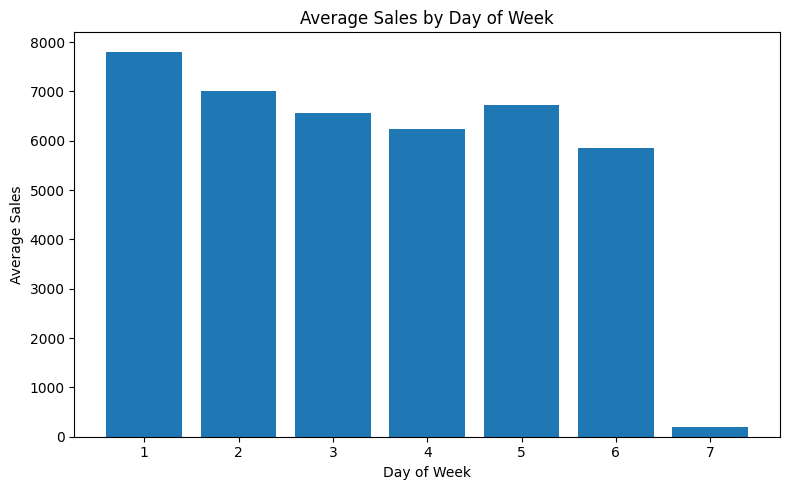

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

avg_sales_by_day = train.groupby("DayOfWeek")["Sales"].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(avg_sales_by_day.index, avg_sales_by_day.values)

ax.set_title("Average Sales by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Sales")
ax.set_xticks(range(1, 8))

plt.tight_layout()

display(fig)
plt.close(fig)

In [ ]:
# Check store opening rate and sales by day of week

day_analysis = train.groupby("DayOfWeek").agg(
    Average_Sales=("Sales", "mean"),
    Open_Rate=("Open", "mean")
)

day_analysis["Open_Rate"] = day_analysis["Open_Rate"] * 100

display(day_analysis.round(2))

,Average_Sales,Open_Rate
DayOfWeek,,
1,7809.04,95.05
2,7005.24,98.83
3,6555.88,97.44
4,6247.58,92.32
5,6723.27,95.06
6,5847.56,99.54
7,204.18,2.48


In [ ]:
# Create a separate copy for preprocessing
data = train.copy()

# Convert Date from text to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Extract useful date features
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["WeekOfYear"] = data["Date"].dt.isocalendar().week.astype(int)

# Remove the original Date column
data = data.drop(columns=["Date"])

print("Preprocessing started...")
print("New dataset shape:", data.shape)

print("\nNew columns:")
print(data.columns.tolist())

display(data.head())

Preprocessing started...
New dataset shape: (1017209, 12)

New columns:
['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear']


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear
0,1,5,5263,555,1,1,0,1,2015,7,31,31
1,2,5,6064,625,1,1,0,1,2015,7,31,31
2,3,5,8314,821,1,1,0,1,2015,7,31,31
3,4,5,13995,1498,1,1,0,1,2015,7,31,31
4,5,5,4822,559,1,1,0,1,2015,7,31,31


In [ ]:
print("StateHoliday values:")
print(data["StateHoliday"].value_counts())

print("\nStateHoliday data type:")
print(data["StateHoliday"].dtype)

StateHoliday values:
StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

StateHoliday data type:
object


In [ ]:
# Convert StateHoliday into numerical features
data = pd.get_dummies(
    data,
    columns=["StateHoliday"],
    prefix="StateHoliday",
    dtype=int
)

print("StateHoliday converted successfully.")

print("\nNew columns:")
print(data.columns.tolist())

display(data.head())

StateHoliday converted successfully.

New columns:
['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear', 'StateHoliday_0', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,Year,Month,Day,WeekOfYear,StateHoliday_0,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,1,5,5263,555,1,1,1,2015,7,31,31,0,1,0,0,0
1,2,5,6064,625,1,1,1,2015,7,31,31,0,1,0,0,0
2,3,5,8314,821,1,1,1,2015,7,31,31,0,1,0,0,0
3,4,5,13995,1498,1,1,1,2015,7,31,31,0,1,0,0,0
4,5,5,4822,559,1,1,1,2015,7,31,31,0,1,0,0,0


In [ ]:
# Rebuild the preprocessing cleanly

data = train.copy()

# Convert StateHoliday to text consistently
data["StateHoliday"] = data["StateHoliday"].astype(str)

# Convert Date to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Create date-based features
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["WeekOfYear"] = data["Date"].dt.isocalendar().week.astype(int)

# Remove original Date column
data = data.drop(columns=["Date"])

# One-hot encode StateHoliday
data = pd.get_dummies(
    data,
    columns=["StateHoliday"],
    prefix="StateHoliday",
    dtype=int
)

print("Clean preprocessing completed.")
print("Dataset shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

display(data.head())


Clean preprocessing completed.
Dataset shape: (1017209, 15)

Columns:
['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,Year,Month,Day,WeekOfYear,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,1,5,5263,555,1,1,1,2015,7,31,31,1,0,0,0
1,2,5,6064,625,1,1,1,2015,7,31,31,1,0,0,0
2,3,5,8314,821,1,1,1,2015,7,31,31,1,0,0,0
3,4,5,13995,1498,1,1,1,2015,7,31,31,1,0,0,0
4,5,5,4822,559,1,1,1,2015,7,31,31,1,0,0,0


In [ ]:
# Define input features (X) and target variable (y)

features = [
    "Store",
    "DayOfWeek",
    "Open",
    "Promo",
    "SchoolHoliday",
    "Year",
    "Month",
    "Day",
    "WeekOfYear",
    "StateHoliday_0",
    "StateHoliday_a",
    "StateHoliday_b",
    "StateHoliday_c"
]

X = data[features]
y = data["Sales"]

print("Input features:", X.columns.tolist())
print("\nNumber of input features:", X.shape[1])
print("Target variable:", y.name)
print("X shape:", X.shape)
print("y shape:", y.shape)

Input features: ['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']

Number of input features: 13
Target variable: Sales
X shape: (1017209, 13)
y shape: (1017209,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'scipy'

In [ ]:
import sys

print("Python used by notebook:")
print(sys.executable)

print("\nTesting SciPy...")
import scipy
print("SciPy version:", scipy.__version__)

print("\nTesting scikit-learn...")
import sklearn
print("scikit-learn version:", sklearn.__version__)

Python used by notebook:
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\python.exe

Testing SciPy...
SciPy version: 1.18.1

Testing scikit-learn...


ModuleNotFoundError: No module named 'narwhals'